# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [2]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Interpretation:

The code sets up the notebook in order to run R code inside a Python Jupyter environment. Moreover, The %load_ext rpy2.ipython line enables the rpy2 extension, allowing R and Python to work together in the same notebook. It also uses the warnings module to hide warning messages, which keeps the output cleaner and easier to read.

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

# Print the number of rows
print(len(raw_data))

7214


Interpretation:

The pd.read_csv(url) function reads the CSV file from the given URL and stores it in a DataFrame called raw_data. In addition print(len(raw_data)), shows how many rows (records) are in the dataset which 7214 rows or number of observations

In [4]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


Interpretation :

Showing the first 10 rows

However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [ ]:
import pandas as pd

numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = (
    raw_data[
        [
            "age", "c_charge_degree", "race", "age_cat",
            "score_text", "sex", "priors_count",
            "days_b_screening_arrest", "decile_score", "is_recid",
            "two_year_recid", "c_jail_in", "c_jail_out"
        ]
    ]
    .loc[lambda x: x["days_b_screening_arrest"].between(-30, 30)]
    .loc[lambda x: x["is_recid"] != -1]
    .loc[lambda x: x["c_charge_degree"] != "O"]
    .loc[lambda x: x["score_text"] != "N/A"]
    .copy()
)

# Type conversions
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True, errors="coerce")

for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Derived factors with reference-like category ordering
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].dropna().unique() if c != "25 - 45"],
    ordered=False
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].dropna().unique() if c != "Caucasian"],
    ordered=False
)

# Match R factor(sex, labels = c("Female", "Male"))
# Assumes original categories are ordered alphabetically or as in the source data.
# Safer version:
sex_map = {df["sex"].dropna().unique()[0]: "Female", df["sex"].dropna().unique()[1]: "Male"}
df["gender_factor"] = df["sex"].map(sex_map)
df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],
    ordered=False
)

df["score_factor"] = pd.Categorical(
    df["score_text"].ne("Low").map({False: "LowScore", True: "HighScore"}),
    categories=["LowScore", "HighScore"],
    ordered=False
)

n_rows = len(df)
print(n_rows)

6172


Interpretation 🇰

To filters messy data, fixes data types, and createilters messy data, fixes data types, and cretes clean, structured variables ready for modeling or analysis.

In [ ]:
df.head(6)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Female,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Female,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Female,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Female,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Female,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23+00:00,2013-08-30 08:42:13+00:00,F,25 - 45,Other,Female,LowScore


Interpretation 🇰
To shows the first 6 rows of the cleaned dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Interpretation 🇰

There are 6,172 rows and 18 columns, meaning the dataset includes 6,172 individuals with 18 variables each. All columns have no missing values, so the data is complete.

Most variables are categorical (such as race, gender, and risk level), while some are numeric (such as age and priore age and priors count), and the jail dates are stored in datetime format.

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [ ]:
# Convert to datetime (if not already)
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])

# Create length_of_stay (in days)
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Correlation
correlation = df["length_of_stay"].corr(df["decile_score"])

print(correlation)

0.20747808478031807


Interpretation 🇰

The code examines the relationship between COMPAS risk scores and how long someone stays in jail.

Firstly, it converts the jail entry and exit dates into a  converts the jail entry and exit dates into datetime format, then calculates a new variable called length_of_stay (in days). After that, it measures the correlation between length_of_stay and the COMPAS score (decile_score).

The correlation is about 0.21, indicating a weak positive relationship.

After filtering we have the following demographic breakdown:

In [ ]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


Interpretation:

The output shows how individuals are distributed across age groups after filtering the data. Meanwhile the majority are in the 25–45 age group (3532 people), making it the largest group. The other groups—less than 25 (1347) and greater than 45 (1293)—are smaller and close in size.

In [ ]:
summary = df["race"].value_counts().to_frame("count")
summary["percent"] = df["race"].value_counts(normalize=True) * 100
print(summary)

                  count    percent
race                              
African-American   3175  51.441996
Caucasian          2103  34.073234
Hispanic            509   8.246922
Other               343   5.557356
Asian                31   0.502268
Native American      11   0.178224


Interpretation 🇰

Most individuals are African-American (about 51.4%), followed by Caucasian (34.1%). Smaller portions include Hispanic (8.2%) and Other (5.6%), while Asian (0.5%) and Native American (0.2%) represent very small groups.

In [ ]:
print("Black defendants: %.2f%%" % (3175 / 6172 * 100))
print("White defendants: %.2f%%" % (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" % (509  / 6172 * 100))
print("Asian defendants: %.2f%%" % (31   / 6172 * 100))
print("Native American defendants: %.2f%%" % (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


Interpretation:

The largest group is Black defendants (51.44%), followed by White defendants (34.07%). The other groups are much smaller, including Hispanic (8.25%), Asian (0.50%), and Native American (0.18%).

In [ ]:
summary = df["score_text"].value_counts().to_frame("count")
summary["percent"] = df["score_text"].value_counts(normalize=True) * 100
print(summary)

            count    percent
score_text                  
Low          3421  55.427738
Medium       1607  26.036941
High         1144  18.535321


Interpretation:

The output shows the distribution of defendants across COMPAS risk levels.
The largest group is Low risk (55.4%), followed by Medium risk (26.0%), and High risk (18.5%).

In [ ]:
ct = pd.crosstab(df["sex"], df["race"])
print(ct)

print("\nRow %:")
print(pd.crosstab(df["sex"], df["race"], normalize="index") * 100)

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285

Row %:
race    African-American     Asian  Caucasian  Hispanic  Native American  \
sex                                                                        
Female         46.723404  0.170213  41.021277  6.978723         0.170213   
Male           52.551531  0.580348  32.439464  8.545127         0.180108   

race       Other  
sex               
Female  4.936170  
Male    5.703422  


Interpretation 🇰

The output shows how race is distributed across gender. Most individuals are male, and this trend appears across all racial groups. The largest groups for both males and females are African-American and Caucasian.
- Among females, about 46.7% are African-American and 41.0% are Caucasian
- Among males, about 52.6% are African-American and 32.4% are Caucasian

In [ ]:
df["sex"].value_counts(dropna=False)

,count
sex,
Male,4997
Female,1175


Interpretation 🇰

The output shows how individuals are distributed by gender.
Most of the dataset consists of males (4997), while females (1175) represent a smaller group.

In [ ]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


Interpretation:

The output shows the percentage distribution of gender in the dataset.
About 80.96% are men, while 19.04% are women, indicating a strong imbalance.

In [ ]:
recid_count = (df["two_year_recid"] == 1).sum()
print(recid_count)

2809


Interpretation:

The output shows the number of individuals who reoffended within two years.
A total of 2,809 individuals have two_year_recid = 1, meaning they were rearrested within two years.

In [ ]:
recid_rate = (df["two_year_recid"] == 1).mean() * 100
print(recid_rate)

45.51198963058976


Interpretation:

The output shows the recidivism rate in the dataset, which about 45.51% of individuals reoffended within two years.

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

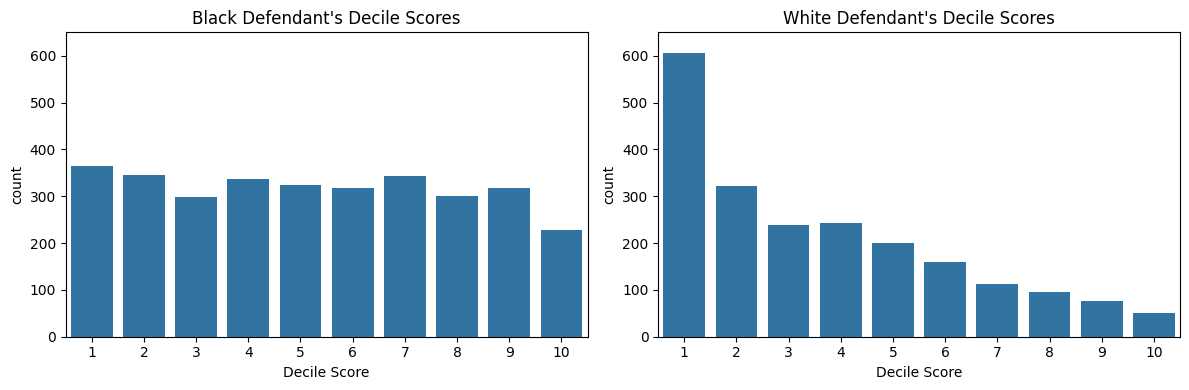

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data
df_black = df[df["race"] == "African-American"]
df_white = df[df["race"] == "Caucasian"]

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot for Black defendants
sns.countplot(
    data=df_black,
    x="decile_score",
    order=sorted(df["decile_score"].dropna().unique()),
    ax=axes[0]
)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylim(0, 650)

# Plot for White defendants
sns.countplot(
    data=df_white,
    x="decile_score",
    order=sorted(df["decile_score"].dropna().unique()),
    ax=axes[1]
)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

Interpretation 🇰

- For Black defendants, the scores are more evenly spread across all deciles (1–10), meaning they are distributed across both low and high risk levels.

- For White defendants, the scores are heavily concentrated in the lower deciles (especially 1–3), and decrease steadily as the score increases.

In [ ]:
ct = pd.crosstab(df["decile_score"], df["race"])
print(ct)

print("\nRow %:")
print(pd.crosstab(df["decile_score"], df["race"], normalize="index") * 100)

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

Interpretation 🇰

At lower scores (1–3), a larger share of defendants are Caucasian, while at higher scores (7–10), the proportion of African-American defendants increases. As the score rises, the share of African-American individuals goes up, while the share of Caucasian individuals goes down.

Meanwhile, other racial groups (Hispanic, Asian, Native American, and Other) appear in smaller proportions across all score levels.

## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

df_model = df.copy()

# safest binary outcome: LowScore = 0, HighScore = 1
df_model["score_factor_num"] = np.where(df_model["score_text"] == "Low", 0, 1).astype(int)

# categorical predictors
cat_vars = ["gender_factor", "age_factor", "race_factor", "crime_factor"]
for col in cat_vars:
    df_model[col] = df_model[col].astype("category")

# check target before fitting
print(df_model["score_factor_num"].dtype)
print(df_model["score_factor_num"].value_counts(dropna=False))

model_glm = smf.logit(
    "score_factor_num ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df_model
).fit()

print(model_glm.summary())

int64
score_factor_num
0    3421
1    2751
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       score_factor_num   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        12:25:11   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

Interpretation:

The model checks whether race affects the chance of getting a high COMPAS score, while controlling for other factors like age, gender, prior offenses, crime type, and recidivism.

Additionally, The results show that race still matters. African-American defendants are more likely to receive a high risk score, while some other groups are less likely compared to the reference group.

Other important factors:
- Younger people (<25) are more likely to get high scores
- More prior offenses increase the chance of a high score
- People who reoffend are more likely to have high scores
- Females are slightly less likely to get high scores

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [ ]:
import numpy as np

# baseline probability (control)
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

# adjusted probability using coefficient
result = np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

print(control)
print(result)

0.17864717443340628
1.4528408658138932


Interpretation:

The code converts the regression results into probabilities.

The baseline probability of receiving a high score is about 17.9%. After accounting for the race coefficient, the result shows that Black defendants are about 1.45 times (or 45%) more likely to receive a higher score compared to White defendants. Thus, even after controlling for other factors, Black defendants still have a higher chance of being labeled high risk.

Women are 19.4% more likely than men to get a higher score.

In [ ]:
import numpy as np

result = np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

print(result)

1.1947978508506671


Interpretation:

The code converts the gender coefficient.

The result (about 1.19) means that women are around 19% more likely than men to receive a higher COMPAS score, after accounting for other factors.

Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [ ]:
import numpy as np

result = np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

print(result)

2.4961202077189455


Interpretation:

The code converts the age effect

The result (about 2.5) means that people under 25 are about 2.5 times more likely to receive a higher COMPAS score compared to middle-aged individuals, after controlling for other factors.

In [ ]:
# Predicted probabilities
df_model["pred_prob"] = model_glm.predict(df_model)

# Predicted class (threshold = 0.5)
df_model["pred_class"] = (df_model["pred_prob"] >= 0.5).astype(int)

# Convert to labels like R
df_model["pred_class"] = df_model["pred_class"].map({
    0: "No Recid",
    1: "Recid"
})

Interpretation:

This code uses the logistic regression model to make predictions.

First, it calculates the predicted probability (pred_prob) that each individual will be classified as high risk. Then, it converts these probabilities into a predicted class using a threshold of 0.5:
- If probability ≥ 0.5 → predicted as Recid (high risk)
- If probability < 0.5 → predicted as No Recid (low risk)

Thus, it replaces the numeric labels (0 and 1) with more readable categories.

In [ ]:
import pandas as pd

print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

# Confusion matrix (like table in R)
overall_cm = pd.crosstab(
    df_model["pred_class"],
    df_model["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

# Extract values
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

# Metrics
accuracy  = (TP + TN) / n
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
fpr       = FP / (FP + TN)
fnr       = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


Interpretation:

The output evaluates how well the model predicts recidivism.
The confusion matrix shows that the model correctly predicts many cases, but also makes some mistakes. Overall, the model has an accuracy of 73.2%, meaning it correctly classifies about 7 out of 10 individuals.

- Precision (72.4%): when the model predicts someone will reoffend, it is correct most of the time

- Recall (66.4%): the model identifies about two-thirds of actual reoffenders

- FPR (21.1%): some people who do not reoffend are incorrectly predicted as reoffenders

- FNR (33.6%): about one-third of actual reoffenders are missed

In [ ]:
import pandas as pd

print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────")

# Create helper columns
df_model["actual"] = df_model["two_year_recid"].astype(int)
df_model["pred"] = (df_model["pred_class"] == "Recid").astype(int)

# Group by race and compute metrics
race_metrics = (
    df_model
    .groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

# Add metrics
race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by sample size
race_metrics = race_metrics.sort_values(by="n", ascending=False)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────
               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


Interpretation 🇰

The output evaluates model performance separately for each racial group.

Overall accuracy is fairly similar across groups (around 70–77%), but the error patterns differ a lot:

- African-American defendants have a higher recall (82.7%), meaning the model correctly identifies most who reoffend, but also a higher false positive rate (36.7%), meaning more people are incorrectly labeled as high risk.

- Caucasian defendants have a lower false positive rate (10.4%), but a higher false negative rate (53.6%), meaning many actual reoffenders are missed.

- Hispanic and Other groups show similar patterns to Caucasians, with low false positives but high false negatives.

In [ ]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

# Select relevant columns
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get Caucasian baseline
baseline_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
baseline_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute disparities
disparity["delta_FPR"] = (disparity["FPR"] - baseline_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - baseline_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


Interpretation 🇰

The output compares error rates across racial groups using Caucasian defendants as the baseline.

- African-American defendants have a much higher false positive rate (+0.263) and a lower false negative rate (−0.363). This means they are more likely to be incorrectly labeled as high risk, but less likely to be missed if they actually reoffend.

- Caucasian defendants (baseline) have lower false positives but higher false negatives, meaning the model misses more actual reoffenders.

- Hispanic, Asian, and Other groups generally have lower false positive rates but higher false negative rates, similar to Caucasians.

- Native American group shows extreme values, but the sample size is very small, so results may not be reliable.

Thus, it tends to flag African-American individuals as high risk more often (even when incorrect), while it tends to miss more true reoffenders among other groups, especially Caucasians. This highlights disparities in error types across races.

# Task
To implement the data preparation and filtering steps as outlined in the plan, I'll write and execute Python code in the next cell. This will involve:

1.  Defining the `numeric_vars` and `datetime_vars` lists.
2.  Selecting the specified columns from `raw_data` to create a new DataFrame `df`.
3.  Applying the filtering conditions to `df`.
4.  Converting `c_jail_in` and `c_jail_out` to datetime objects.
5.  Converting other non-numeric and non-datetime columns to categorical types.
6.  Creating the derived categorical features: `crime_factor`, `age_factor`, `race_factor`, `gender_factor`, and `score_factor`.
7.  Finally, printing the number of rows in the resulting `df`.

## Prepare Data for Conversion

### Subtask:
Define the numeric and datetime variable names to be used for type conversions, similar to how they are defined in the R code.


**Reasoning**:
The subtask requires defining `numeric_vars` and `datetime_vars` lists in Python. This code block will create these lists with the specified column names, preparing the data for further processing.



In [ ]:
numeric_vars = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
datetime_vars = ['c_jail_in', 'c_jail_out']

print(f"Numeric variables: {numeric_vars}")
print(f"Datetime variables: {datetime_vars}")

Numeric variables: ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
Datetime variables: ['c_jail_in', 'c_jail_out']


Interpretation:

It defines which variables are numeric and which are datetime.
The numeric_vars list includes variables like age, prior offenses, and risk score, while datetime_vars includes the jail entry and exit dates.

**Reasoning**:
Now that the variable lists are defined, the next step is to select the specified columns from the `raw_data` DataFrame and assign them to a new DataFrame called `df`.



In [ ]:
selected_cols = ['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
                 'priors_count', 'days_b_screening_arrest', 'decile_score',
                 'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']

df = raw_data[selected_cols].copy()

print(f"DataFrame 'df' created with {df.shape[0]} rows and {df.shape[1]} columns.")
print("First 5 rows of df:")
print(df.head())

DataFrame 'df' created with 7214 rows and 13 columns.
First 5 rows of df:
   age c_charge_degree              race          age_cat score_text   sex  \
0   69               F             Other  Greater than 45        Low  Male   
1   34               F  African-American          25 - 45        Low  Male   
2   24               F  African-American     Less than 25        Low  Male   
3   23               F  African-American     Less than 25       High  Male   
4   43               F             Other          25 - 45        Low  Male   

   priors_count  days_b_screening_arrest  decile_score  is_recid  \
0             0                     -1.0             1         0   
1             0                     -1.0             3         1   
2             4                     -1.0             4         1   
3             1                      NaN             8         0   
4             2                      NaN             1         0   

   two_year_recid            c_jail_in          

Interpretation:

It selects important columns from the original dataset and creates a new DataFrame called df. Moreover, the new dataset contains 7,214 rows and 13 columns, focusing only on relevant variables like demographics, risk scores, prior offenses, and recidivism.

**Reasoning**:
The next step is to apply the filtering conditions to the DataFrame `df` as outlined in the R code. This will reduce the dataset to only relevant entries for the analysis.



In [ ]:
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']

print(f"DataFrame 'df' after filtering has {df.shape[0]} rows.")
print("First 5 rows of filtered df:")
print(df.head())

DataFrame 'df' after filtering has 6172 rows.
First 5 rows of filtered df:
   age c_charge_degree              race          age_cat score_text   sex  \
0   69               F             Other  Greater than 45        Low  Male   
1   34               F  African-American          25 - 45        Low  Male   
2   24               F  African-American     Less than 25        Low  Male   
5   44               M             Other          25 - 45        Low  Male   
6   41               F         Caucasian          25 - 45     Medium  Male   

   priors_count  days_b_screening_arrest  decile_score  is_recid  \
0             0                     -1.0             1         0   
1             0                     -1.0             3         1   
2             4                     -1.0             4         1   
5             0                      0.0             1         0   
6            14                     -1.0             6         1   

   two_year_recid            c_jail_in         

Interpretation:

It filters the dataset to keep only valid and relevant records.
After applying the conditions, the dataset is reduced to 6,172 rows, removing missing or invalid values (such as unclear scores or incorrect entries).

**Reasoning**:
Now that the filtering is complete, the next logical step is to perform the type conversions as outlined in the R code, starting with converting 'c_jail_in' and 'c_jail_out' columns to datetime objects.



In [ ]:
for col in datetime_vars:
    # Using errors='coerce' to turn unparseable dates into NaT (Not a Time)
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d %H:%M:%S', errors='coerce')

print(f"Data types after converting datetime columns: {df[datetime_vars].dtypes.to_dict()}")
print("First 5 rows of df with converted datetime columns:")
print(df[datetime_vars].head())

Data types after converting datetime columns: {'c_jail_in': dtype('<M8[ns]'), 'c_jail_out': dtype('<M8[ns]')}
First 5 rows of df with converted datetime columns:
            c_jail_in          c_jail_out
0 2013-08-13 06:03:42 2013-08-14 05:41:20
1 2013-01-26 03:45:27 2013-02-05 05:36:53
2 2013-04-13 04:58:34 2013-04-14 07:02:04
5 2013-11-30 04:50:18 2013-12-01 12:28:56
6 2014-02-18 05:08:24 2014-02-24 12:18:30


Interpretation:

It converts the jail entry and exit columns into proper datetime format.
After conversion, both c_jail_in and c_jail_out are stored as datetime variables, making it possible to work with dates correctly (e.g., calculate time differences).